## 7.1

In [21]:
import numpy as np
from numpy import linalg as la
M = np.array([1,2,3,  0,-4,1,  0,3,-1]).reshape(3,3)
print("M=")
print(M)
det = la.det(M)
print(f"The determinant of matrix M is: {det} ")

A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print(f"Matrix A:\n{A}")
b = np.array([2,2,1])
X = la.solve(A,b)
x, y, z = X
print(f" The solution to this system of equations is: x = {x}, y = {y}, z  = {z}")
# A transpose should be equal to A inverse.
Ainv = la.inv(A)
Atrans = A.T
print("We subtract Atrans from Ainv, if this results in an all zeros matrix, A is orthogonal, otherwise not.")
print(Ainv-Atrans)
print("A is not orthogonal")

Lambda, v = la.eig(A)
print(f" The eigenvalues of A are: {Lambda} ")


M=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
The determinant of matrix M is: 1.0 
Matrix A:
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
 The solution to this system of equations is: x = 38.0, y = -3.0, z  = -10.0
We subtract Atrans from Ainv, if this results in an all zeros matrix, A is orthogonal, otherwise not.
[[ 0. 11. 14.]
 [-2.  3. -4.]
 [-3. -4. -3.]]
A is not orthogonal
 The eigenvalues of A are: [ 1.         -4.79128785 -0.20871215] 


## 7.3

In [23]:
import numpy as np
# We set up three different variables for angles, since there are three required
beta = np.deg2rad(62.6)
gamma2 = np.deg2rad(192.25)
gamma1 = np.deg2rad(57)
# We set up three different rotation matrices.
Ey = np.array([np.cos(beta),0,-np.sin(beta),  0,1,0,  np.sin(beta),0,np.cos(beta)]).reshape(3,3)
Ez1 = np.array([np.cos(gamma1),np.sin(gamma1),0,  -np.sin(gamma1), np.cos(gamma1),0,  0,0,1]).reshape(3,3)
Ez2 = np.array([np.cos(gamma2),np.sin(gamma2),0,  -np.sin(gamma2), np.cos(gamma2),0,  0,0,1]).reshape(3,3)

E = Ez1 @ Ey @ Ez2
print(E)
# The determinant of a rotation matrix is 1, so by calculating the determinant and receiving 1, we show that the matrix is indeed a rotation matrix.
from numpy import linalg as la
det = la.det(E)
print(f" The determinant is {det}, so the matrix is indeed a rotation matrix.")
Lambda, v = la.eig(E)
print(f" The eigenvalues of A are: {Lambda} ")
# Yet again, we set up the different angles for the matrix
alpha = np.deg2rad(192.25)
delta = np.deg2rad(27.4)
V = np.array([
    [ np.cos(delta) * np.cos(alpha)],
    [ np.cos(delta) * np.sin(alpha)],
    [ np.sin(delta)]
])
print(V)
length = la.norm(V)
print(length)

rotated_vector = E @ V
print(rotated_vector)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
 The determinant is 1.0, so the matrix is indeed a rotation matrix.
 The eigenvalues of A are: [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ] 
[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]
1.0
[[2.77555756e-17]
 [5.55111512e-17]
 [1.00000000e+00]]


## 7.5

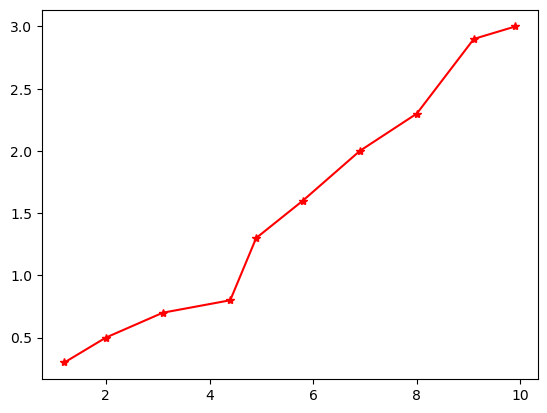

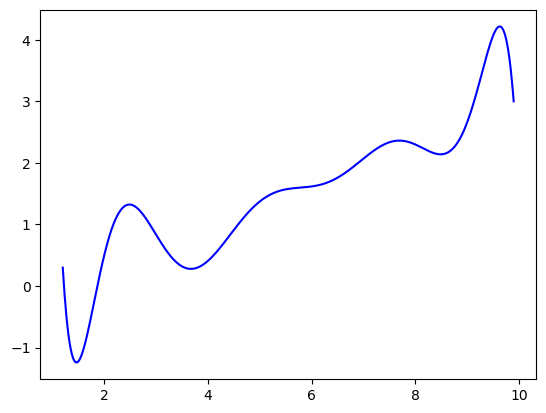

In [12]:
import numpy as np
from matplotlib import pyplot as plt
from numpy import linalg as la
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
n = len(x)
A = np.zeros((n,n))              # Sets up a square matrix with all zeros, in this case a 10 by 10, but will always be n by n.
for i in range(n):
    for j in range(n):
        A[i,j] = x[i]** (n-1-j)
        
coefficients = la.solve(A, y)      # Solves when the matrix is equal to the y-values.

fig, ax = plt.subplots()
ax.plot(x, y, marker = '*', color = 'red')
plt.show()

def polynomial(x_values, coefficients):
    """ This function will calculate the polynomial."""
    n = len(coefficients)
    return sum(coefficients[i] * x_values ** (n-1-i) for i in range(n))
x_plot = np.linspace(x.min(), x.max(), 500)
y_plot = polynomial(x_plot, coefficients)
fig, ax = plt.subplots()
ax.plot(x_plot, y_plot, color = 'blue')
plt.show()

## 7.6

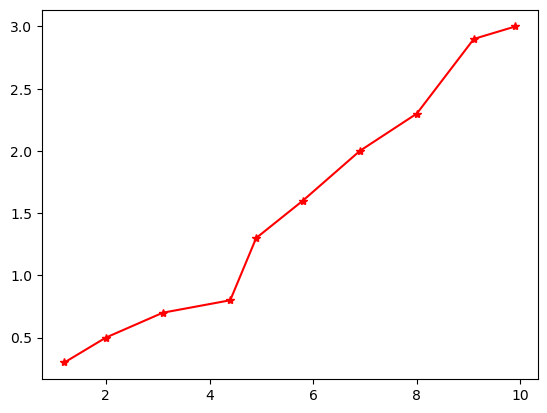

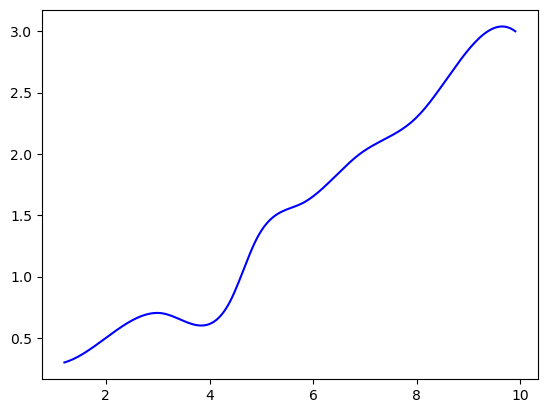

0.5909090909090908
1.3239794637777322
0.6417114521133224


In [31]:
import numpy as np
from matplotlib import pyplot as plt
from numpy import linalg as la
from scipy import interpolate as ip
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

fig, ax = plt.subplots()
ax.plot(x, y, marker = '*', color = 'red')
plt.show()
from scipy import interpolate as ip
f = ip.interp1d(x, y, kind='cubic')
newx = np.linspace(min(x),max(x),200)
newy = f(newx)
fig, ax = plt.subplots()
ax.plot(newx, newy,  color = 'blue')
plt.show()
class interpolation:
    def __init__ (self,x,y):
        self.x = x
        self.y = y
        self.n = len(x)

    def lin(self,x_hat):
        lin_fit = ip.interp1d(self.x, self.y, kind = 'linear' )
        return(lin_fit(x_hat))
    def poly(self, x_hat):
        n = self.n
        A = np.zeros((n,n))              # Sets up a square matrix with all zeros, in this case a 10 by 10, but will always be n by n
        for i in range(n):
            for j in range(n):
                A[i,j] = self.x[i]** (n-1-j)
        coefficients = la.solve(A, self.y)      # Solves when the matrix is equal to the y-values.
        y_hat = np.zeros_like(x_hat, dtype=float)
        for j in range(n):
            y_hat += coefficients[j] * x_hat ** (n-1-j)
        return(y_hat)

    def spline(self, x_hat):
        sp = ip.interp1d(self.x, self.y, kind = 'cubic')
        return sp(x_hat)

    def interpolate(self, x_hat, method = 'linear') :
        if method == 'linear' :
            return self.lin(x_hat)
        elif method == 'polynomial':
            return self.poly(x_hat)
        elif method == 'spline':
            return self.spline(x_hat)
        else:
            print("Wrong method!")
    
x_hat = 2.5
interp = interpolation(x,y)
y_linear = interp.interpolate(x_hat, method = 'linear' )
y_poly = interp.interpolate(x_hat, method = 'polynomial')
y_spline = interp.interpolate(x_hat, method = 'spline')
print(y_linear)
print(y_poly)
print(y_spline)
             

## 7.7

In [19]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= iOnly one TA will be there, so be nice and patient!  <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.2 # Row position is y value
col_x = 0.7  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")



[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.2,0.7 => x, y=0.70.2 is 3.458000


## 7.10

 The parameters are : [69.93805979 64.13233494]
[224.92243799, 66.17289251] [69.93805979 64.13233494]


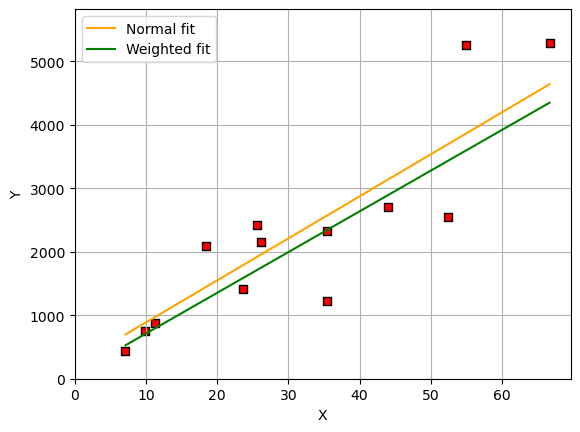

Intercept beta0=9.189492762451197, slope beta1=71.3829624600685


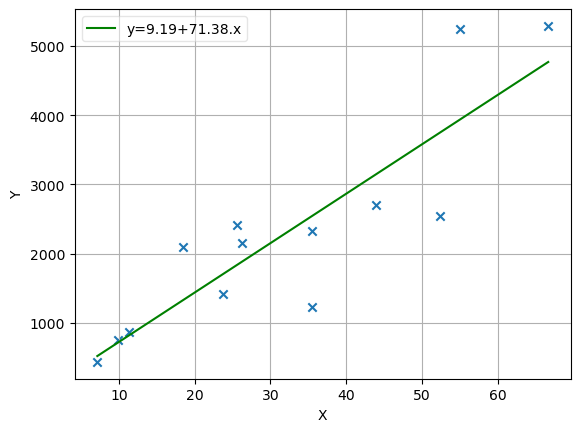

In [44]:
import numpy as np
from scipy.optimize import leastsq
from matplotlib.pyplot import subplots, show, figure
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data = np.asarray(data)
x = data[0::4]; y = data[1::4]
sigx= data[2::4]; sigy= data[3::4]

def model(beta, x):
    beta0, beta1 = beta              # Parameters which are adjusted by leastsq
    return beta0 + beta1*x

def residuals(beta, x, y, sigy):     # Residuals function needed by leastsq
    return (y-model(beta,x))/sigy

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (x, y, sigy)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result   
print(f" The parameters are : {beta}")
beta_lsqwei = beta
beta_lsq = [224.92243799,  66.17289251]

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='s', ec='k', color='r')
xmin = x.min(); xmax = x.max()
ymin = model(beta_lsq,xmin); ymax = model(beta_lsq,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Normal fit", color='orange')
ymin = model(beta_lsqwei,xmin); ymax = model(beta_lsqwei,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Weighted fit", color='green')
print(beta_lsq, beta_lsqwei)
frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*y.max())
frame.grid()
frame.legend()
show()

# Starting the curve_fit part

from scipy.optimize import curve_fit

def model(x, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x

# Do the fitting
beta, pcov = curve_fit(model, x, y)
print(f"Intercept beta0={beta[0]}, slope beta1={beta[1]}")

# Calculate end points for the best straight line
X = np.array([x.min(),x.max()])
Y = model(X, beta[0], beta[1])

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='x')
frame.set_xlabel('X')
frame.set_ylabel('Y')
label = f"y={beta[0]:.2f}+{beta[1]:.2f}.x"
frame.plot(X, Y, label=label, color='green')
frame.legend(fancybox=True, framealpha=0.5)
frame.grid(True)

show()




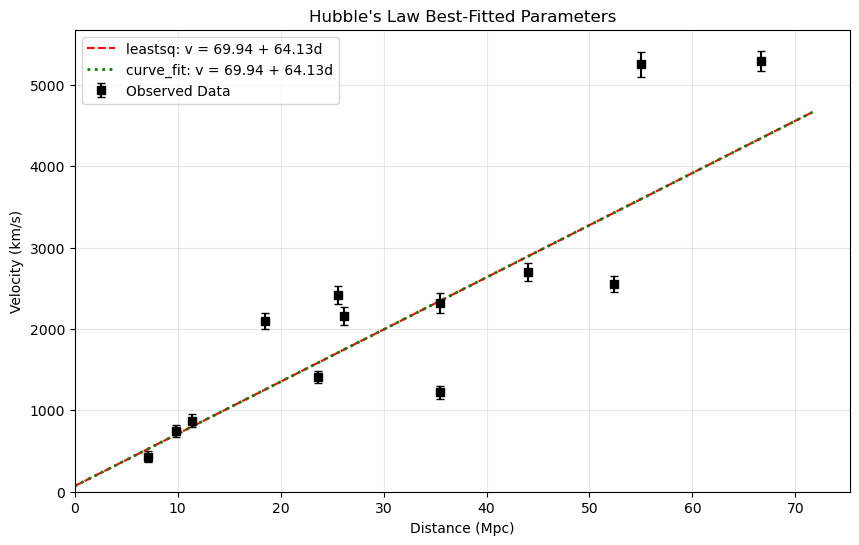

Leastsq Params: Intercept=69.94, Slope=64.13
Curve_fit Params: Intercept=69.94, Slope=64.13


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

# 1. Data Setup
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]
data_list = np.array(data)
d = data_list[0::4]
v = data_list[1::4]
err_v = data_list[3::4]

# 2. Define Models
# For leastsq: beta is a list [intercept, slope]
def model_lsq(beta, d):
    return beta[0] + beta[1] * d

def residuals(beta, d, v, err_v):
    return (v - model_lsq(beta, d)) / err_v

# For curve_fit: parameters are individual
def model_cf(d, b0, b1):
    return b0 + b1 * d

# 3. Perform Fits
beta_start = [0, 70.0]

# Fit 1: leastsq (Weighted)
res_lsq, _ = leastsq(residuals, beta_start, args=(d, v, err_v))

# Fit 2: curve_fit (Weighted)
popt, pcov = curve_fit(model_cf, d, v, p0=beta_start, sigma=err_v, absolute_sigma=True)

# 4. Plotting
plt.figure(figsize=(10, 6))

# Plot data points with error bars and a different marker
plt.errorbar(d, v, yerr=err_v, fmt='s', color='black', label='Observed Data', capsize=3)

# Generate line for plotting
x_fit = np.linspace(0, d.max() + 5, 100)

# Plot Leastsq result
label_lsq = f"leastsq: v = {res_lsq[0]:.2f} + {res_lsq[1]:.2f}d"
plt.plot(x_fit, model_lsq(res_lsq, x_fit), 'r--', label=label_lsq)

# Plot Curve_fit result
label_cf = f"curve_fit: v = {popt[0]:.2f} + {popt[1]:.2f}d"
plt.plot(x_fit, model_cf(x_fit, *popt), 'g:', linewidth=2, label=label_cf)

plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.title("Hubble's Law Best-Fitted Parameters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, None)
plt.ylim(0, None)

plt.show()

print(f"Leastsq Params: Intercept={res_lsq[0]:.2f}, Slope={res_lsq[1]:.2f}")
print(f"Curve_fit Params: Intercept={popt[0]:.2f}, Slope={popt[1]:.2f}")